# e13 campaign results — 0.48 → 0.79 without a textual edge list

**2026-07-21/22.** One session, four experiments, every step a single-flag A/B.
Full decision log: `2026-07-21 e13_nav_pe_setup.md`; gate diagnostic:
`2026-07-21 e13b_decode_style_diagnostic.ipynb`. W&B tags: `e13_nav_pe`,
`e13c_decode_consistent`, `e13d_nav_decode`, `e13e_layer_scope`.

| step | intervention | result |
|---|---|---|
| e11 (ref) | leak-free RPE mask, prompt-only wiring | 0.48 |
| e13 | navigator Ψ (GT+AGT), prompt-only wiring | 0.58 |
| e13c | **decode-consistent injection** (edge-detector Ψ) | **0.73** |
| e13d | decode-consistent × navigator GT | **0.79** |
| — | with-edges reference band | 0.87–0.95 |

The core mechanism (e13c/e13d): train with answer-side mask wiring that is
**exactly reproducible at decode** (mentions act as keys once complete, as
queries at the position where their identity becomes knowable), and extend the
mask to generated mentions during generation (`MaskDecodeInjector`). The model
then reads each hop's legal neighborhood at the moment it commits to the next
hop — hallucination drops 0.17 → 0.035.


In [1]:
import wandb
import pandas as pd

api = wandb.Api()
TAGS = ["e13_nav_pe", "e13c_decode_consistent", "e13d_nav_decode", "e13e_layer_scope"]
rows = []
for tag in TAGS:
    for r in api.runs("alelab/GREP-PRISM", filters={"tags": tag}):
        s = r.summary
        rows.append({"run": r.name, "tag": tag, "acc": s.get("eval/accuracy"),
                     "halluc": s.get("eval/hallucination_rate"),
                     "hop_opt": s.get("eval/path_optimality_rate")})
df = pd.DataFrame(rows).drop_duplicates("run").sort_values("acc", ascending=False)
REFS = pd.DataFrame([
    {"run": "e11_integ_rpe_promptonly (ref)", "tag": "e11", "acc": 0.48, "halluc": None, "hop_opt": None},
    {"run": "e11_gmask_promptonly (ref)", "tag": "e11", "acc": 0.39, "halluc": None, "hop_opt": None},
    # with-edges reference = e10_integ_rpe__with_edge_list_wo83xg96 (W&B), same
    # 10-graph/100-task protocol (twin jfzhel9q: 0.96; e10-era historical band 0.87-0.93).
    {"run": "with-edges RPE wo83xg96 (ref)", "tag": "ref", "acc": 0.95, "halluc": None, "hop_opt": None},
])
df = pd.concat([df, REFS], ignore_index=True).sort_values("acc", ascending=False)
print(df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))


                           run                    tag   acc  halluc  hop_opt
         with-edges RPE wo83xg96 (ref)                    ref 0.950     NaN      NaN
                e13d_gt_decode        e13d_nav_decode 0.790   0.035    1.385
               e13d_agt_decode        e13d_nav_decode 0.790   0.038    1.421
               e13c_rpe_decode e13c_decode_consistent 0.730   0.060    1.451
              e13e_rpe_tophalf       e13e_layer_scope 0.630   0.065    1.450
             e13c_gmask_decode e13c_decode_consistent 0.610   0.088    1.355
                e13_agt_joint3             e13_nav_pe 0.580   0.128    1.310
                e13_agt_joint2             e13_nav_pe 0.480   0.173    1.111
e11_integ_rpe_promptonly (ref)                    e11 0.480     NaN      NaN
                 e13_gt_joint2             e13_nav_pe 0.470   0.162    1.115
                 e13_gt_joint3             e13_nav_pe 0.440   0.209    1.170
    e11_gmask_promptonly (ref)                    e11 0.390     NaN 

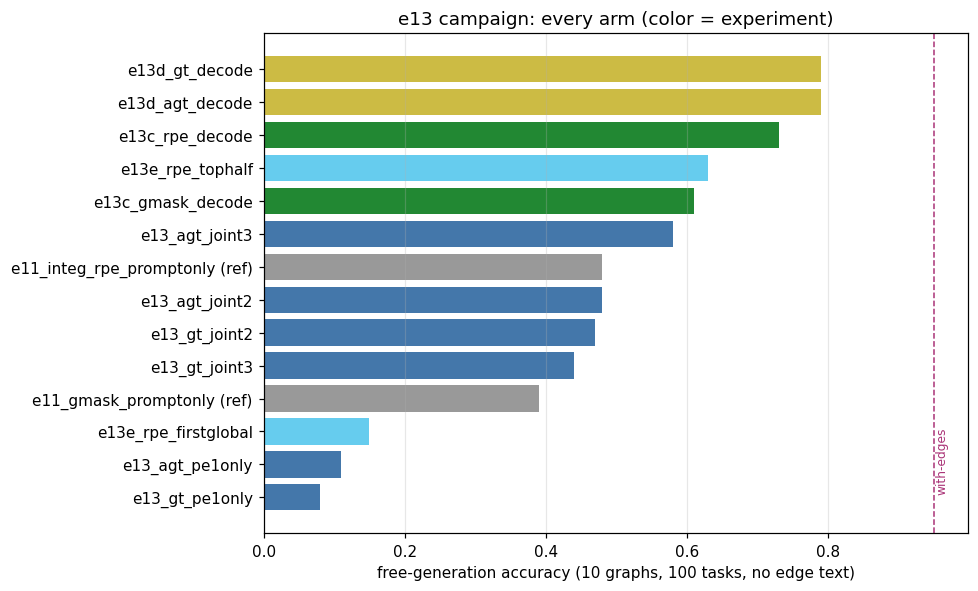

In [2]:
import matplotlib.pyplot as plt

d = df[df.tag != "ref"].dropna(subset=["acc"]).sort_values("acc")
colors = {"e13_nav_pe": "#4477AA", "e13c_decode_consistent": "#228833",
          "e13d_nav_decode": "#CCBB44", "e13e_layer_scope": "#66CCEE", "e11": "#999999"}
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(d.run, d.acc, color=[colors[t] for t in d.tag])
ax.axvline(0.95, color="#AA3377", ls="--", lw=1); ax.text(0.952, 0.2, "with-edges", rotation=90, fontsize=8, color="#AA3377")
ax.set_xlabel("free-generation accuracy (10 graphs, 100 tasks, no edge text)")
ax.set_title("e13 campaign: every arm (color = experiment)")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout(); plt.show()


## Notes on the ladder

- **Ψ content matters less than wiring**: decode-consistent wiring moved
  +0.25/+0.22 (learnable/param-free); swapping edge-detector Ψ for the
  navigation-pretrained GT added +0.06 on top. GT-only ≡ GT+AGT under decode
  wiring (0.79 both) — the AGT's prompt-only advantage (+0.14) was compensating
  for the weaker channel, not adding unique content.
- **Layer scope**: the mask needs all 10 global layers (0.73) — deeper-5 only
  = 0.63, first-global-only = 0.15. The channel is distributed; no compression.
- **Diagnostic** (cell below): the decode-consistent checkpoint reads
  0.861/0.49 nats per decision through its native, generation-legal wiring —
  the leak circuit's old level, now legitimately. Per-decision gap to text
  edges: ~6 points / 0.2 nats.


In [3]:
d = json.load(open("../outputs/e13c_analysis/injection_diag_decode.json"))
print("decision-token diagnostic, e13c_rpe_decode checkpoint (n=519):")
for c in ["no_injection", "prompt_only", "decode_style", "decode_trail", "train_style"]:
    m = d["conditions"][c]["decision"]
    print(f"  {c:14s} acc={m['acc']:.4f}  nll={m['mean_nll']:.3f}")
print("  (with-edges benchmark reference: 0.921 / 0.29 — see e13b notebook)")


decision-token diagnostic, e13c_rpe_decode checkpoint (n=519):
  no_injection   acc=0.5723  nll=2.813
  prompt_only    acc=0.6416  nll=1.995
  decode_style   acc=0.8613  nll=0.490
  decode_trail   acc=0.8555  nll=0.610
  train_style    acc=0.8613  nll=0.490
  (with-edges benchmark reference: 0.921 / 0.29 — see e13b notebook)


In [4]:
import json, glob, collections
import networkx as nx
from prism.data import utils as prism_utils

ev = json.load(open("../outputs/e13c_analysis/e13d_gt_decode_final_eval.json"))
graphs = {}
for f in glob.glob("../data/revised/gen/nav100_n30_gemma_data/split/test_graphs/*.json"):
    stem = f.split("/")[-1].replace(".json", "")
    payload = json.load(open(f))
    G, _ = prism_utils.safe_parse_graph(payload["graph"] if "graph" in payload else payload)
    graphs[stem] = G

fails = [s for s in ev["samples"] if not s["correct"]]
tax = collections.Counter()
dist_hist = collections.Counter()
for s in fails:
    pm = s.get("path_metrics") or {}
    if pm.get("full_path_valid"):
        tax["valid_path_wrong_criterion"] += 1
    elif pm.get("edge_validity_rate", 1) < 1:
        tax["hallucinated_edge_in_route"] += 1
    else:
        tax["other"] += 1
    G = graphs.get(s["graph_name"])
    for a, b in zip(pm.get("parsed_nodes") or [], (pm.get("parsed_nodes") or [])[1:]):
        if G is not None and a in G and b in G and not G.has_edge(a, b):
            try: dist_hist[nx.shortest_path_length(G, a, b)] += 1
            except nx.NetworkXNoPath: dist_hist["inf"] += 1

by_kind = collections.defaultdict(lambda: [0, 0])
for s in ev["samples"]:
    wp = "waypoint/avoid" if ("passing through" in str(s["task"]) or "avoid" in str(s["task"]).lower()) else "plain"
    by_kind[wp][0] += s["correct"]; by_kind[wp][1] += 1
lens = collections.defaultdict(lambda: [0, 0])
for s in ev["samples"]:
    n = (s.get("path_metrics") or {}).get("num_parsed") or 0
    b = "2-3" if n <= 3 else ("4-5" if n <= 5 else "6+")
    lens[b][0] += s["correct"]; lens[b][1] += 1

print(f"failures: {len(fails)}/100   taxonomy: {dict(tax)}")
print(f"hallucinated-edge true distances: {dict(dist_hist)}")
print("acc by task type:", {k: f"{a}/{n}={a/n:.2f}" for k, (a, n) in by_kind.items()})
print("acc by route length:", {k: f"{a}/{n}={a/n:.2f}" for k, (a, n) in sorted(lens.items())})


failures: 21/100   taxonomy: {'hallucinated_edge_in_route': 14, 'valid_path_wrong_criterion': 7}
hallucinated-edge true distances: {3: 3, 2: 10, 4: 2}
acc by task type: {'plain': '50/60=0.83', 'waypoint/avoid': '29/40=0.72'}
acc by route length: {'2-3': '24/28=0.86', '4-5': '44/53=0.83', '6+': '11/19=0.58'}


## Failure profile of the best run (e13d_gt_decode, 0.79)

The residual is narrow: hallucinated single hops inside otherwise-valid routes,
overwhelmingly **distance-2 near-misses** (skipping one intermediate node), plus
a long-route penalty (6+-node routes at 0.58 vs 0.86 short). Formatting,
nonexistent-node, and runtime failures are extinct. This points at two levers:
**legal-next-hop constrained decoding** (mechanically eliminates non-edge hops;
the injector already tracks the current node at the right decode steps) and
long-horizon / waypoint supervision.

Also measured (see conversation log 2026-07-22): the nav-pretrained GT's cosine
sim carries graded proximity (Spearman(sim, −SPD) ≈ +0.32, monotone to ~4 hops,
noisy tail) — relevant to proposals that widen the mask beyond 1-hop pairs
(`mask_k_hops=2`, soft non-edge penalty, or full-N×N soft bias).

## Caveats

Single seed per arm; n=100 tasks (±0.05 s.e.); all numbers 31B, n30 graphs.
The 0.79-vs-0.73 (+0.06) and all ±0.03 deltas are within ~1 s.e. The
0.48→0.73/0.79 jumps are 4–6 s.e. Replication seeds are the next queued run,
alongside the α (adjacency-vs-sim mix) sweep.
